In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND


In [4]:
print("First 5 Rows")
print(df.head())


First 5 Rows
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  


In [5]:
print("\nDataset Information")
print(df.info())




Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB
None


In [6]:
print("\nDataset Shape:", df.shape)



Dataset Shape: (20640, 10)


In [7]:
print("\nStatistical Summary")
print(df.describe())



Statistical Summary
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   

In [8]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [11]:
median_value = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(median_value)

In [12]:
print("\nMissing Values After Cleaning")
print(df.isnull().sum())


Missing Values After Cleaning
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [13]:
print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["ocean_proximity"] = encoder.fit_transform(df["ocean_proximity"])

print("\nEncoded Dataset")
print(df.head())



Encoded Dataset
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value  ocean_proximity  
0         322         126         8.3252              452600                3  
1        2401        1138         8.3014              358500                3  
2         496         177         7.2574              352100                3  
3         558         219         5.6431              341300                3  
4         565         259         3.8462              342200                3  


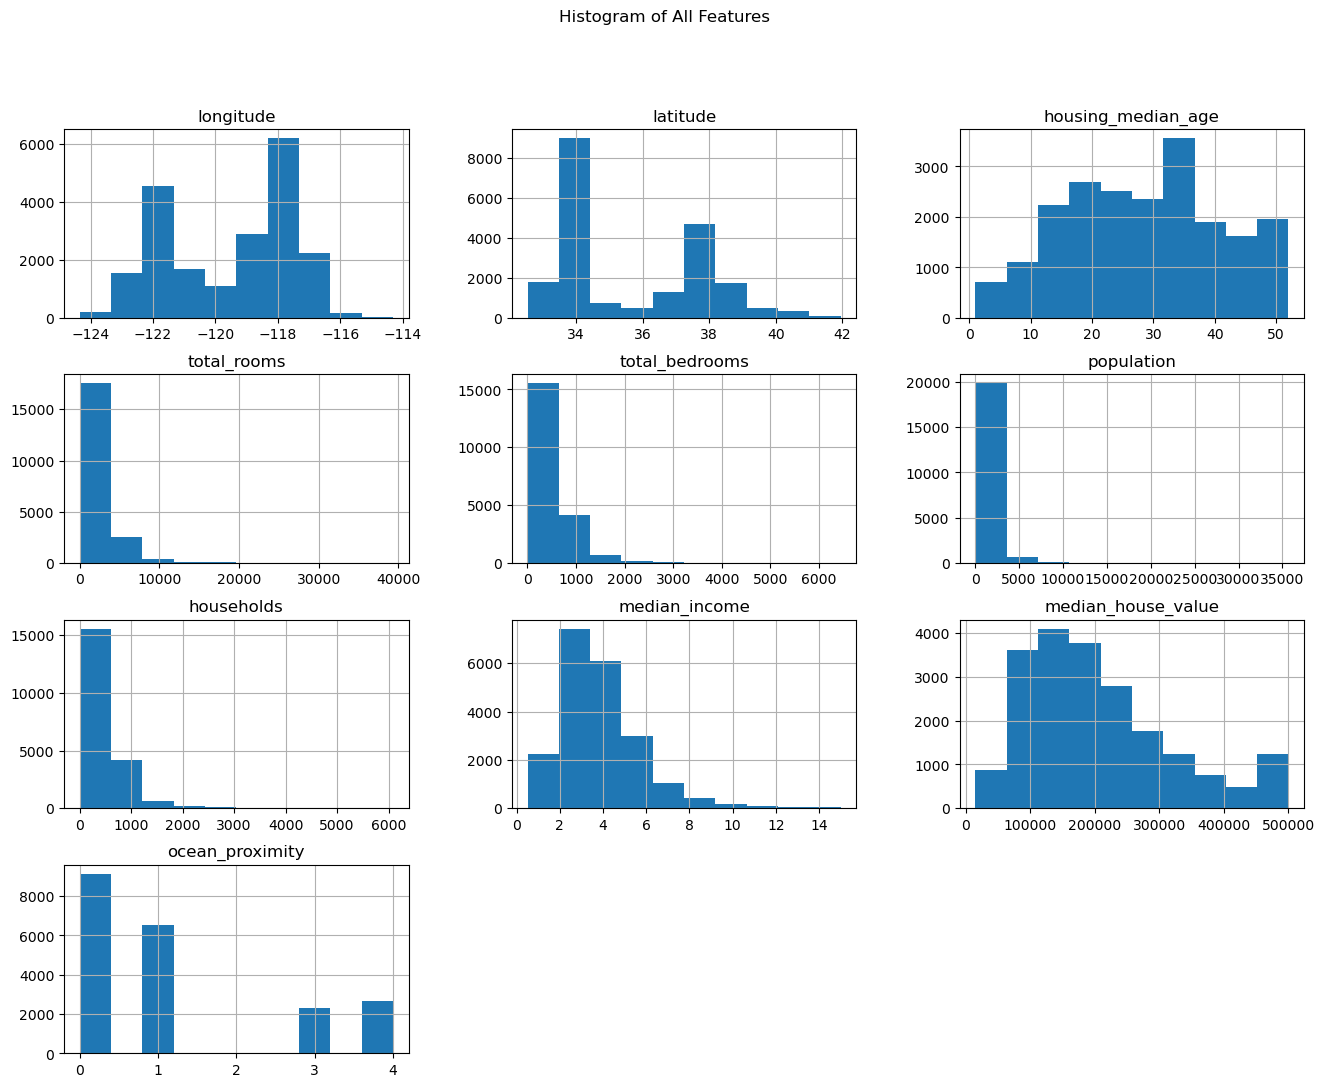

In [15]:
df.hist(figsize=(16,12))
plt.suptitle("Histogram of All Features")
plt.show()

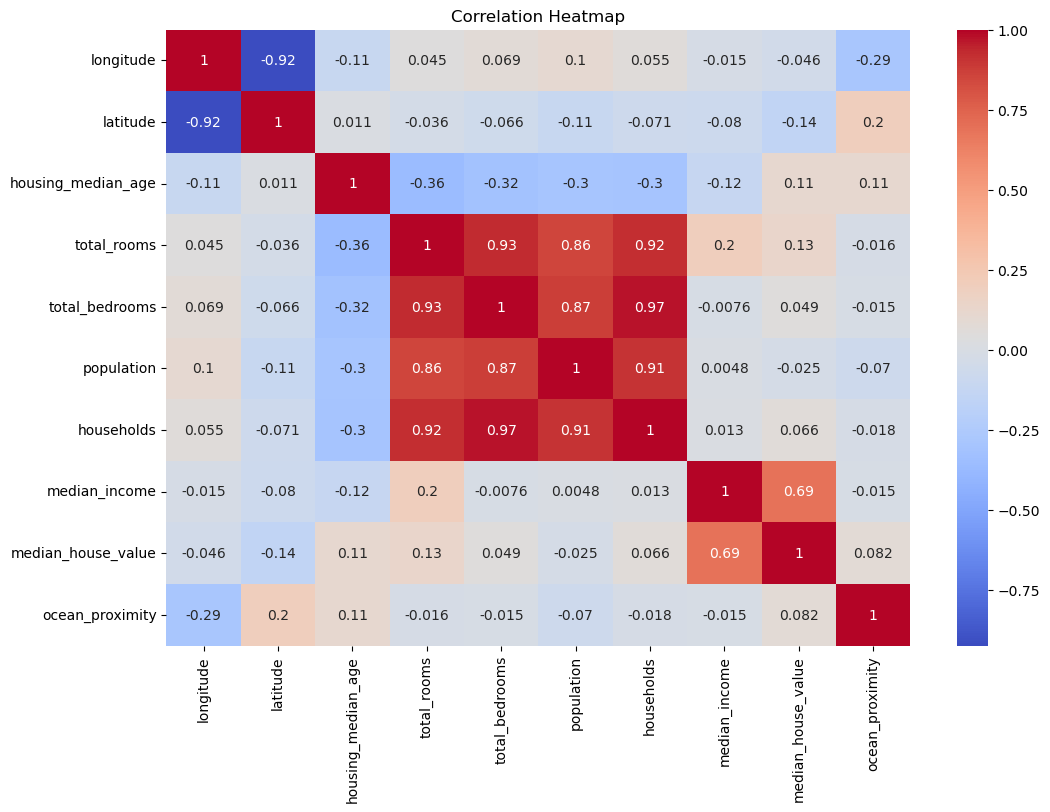

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

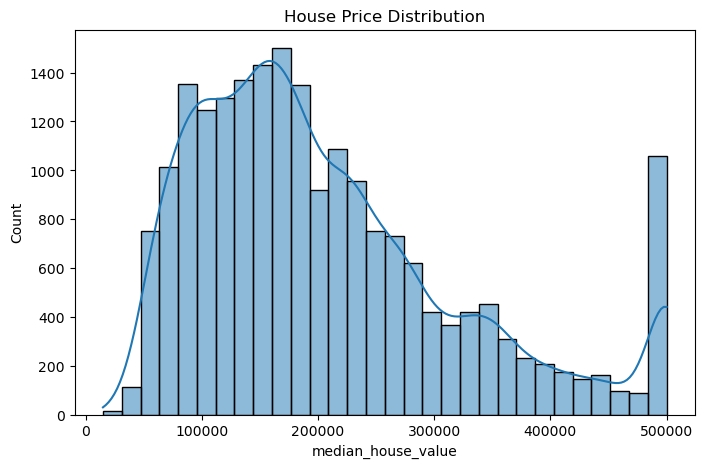

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"],bins=30,kde=True)
plt.title("House Price Distribution")
plt.show()

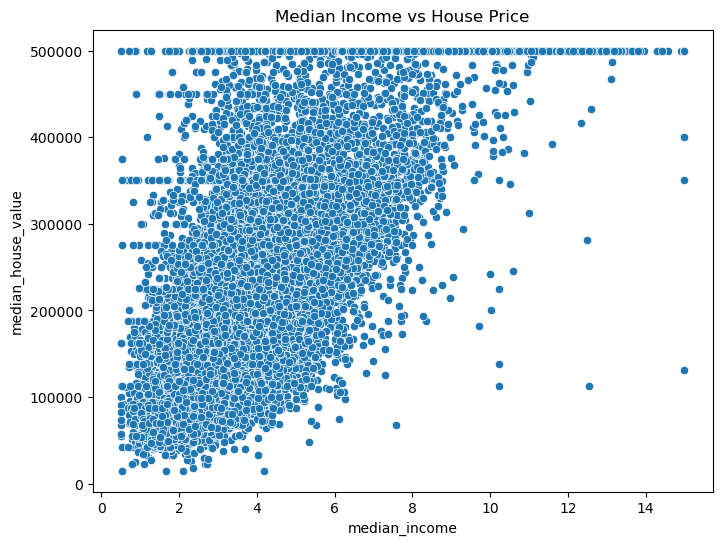

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value"
)
plt.title("Median Income vs House Price")
plt.show()

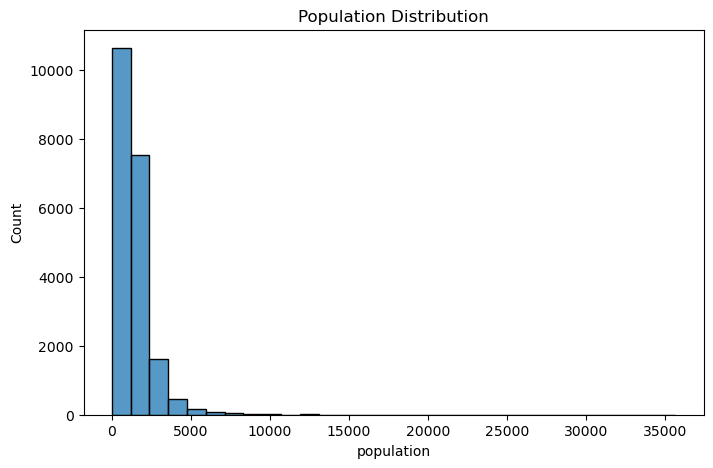

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["population"],bins=30)
plt.title("Population Distribution")
plt.show()


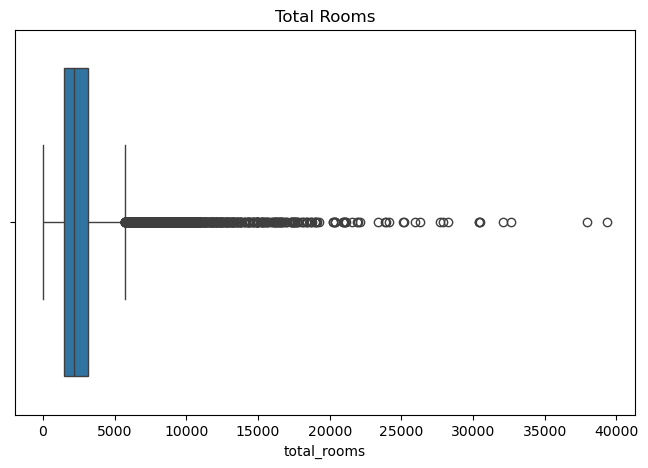

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["total_rooms"])
plt.title("Total Rooms")
plt.show()

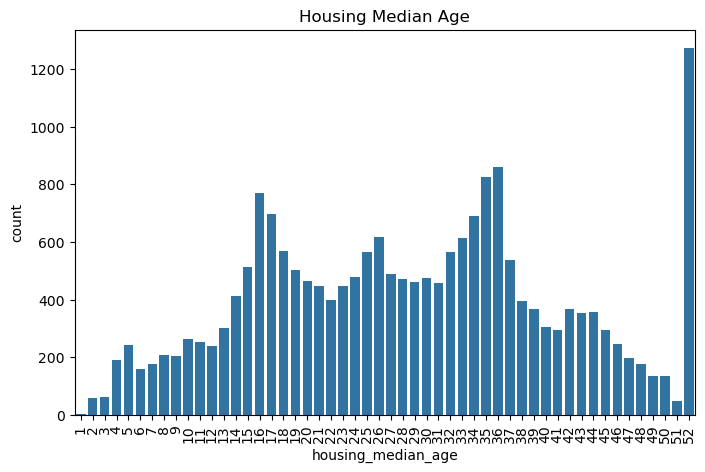

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x="housing_median_age",data=df)
plt.xticks(rotation=90)
plt.title("Housing Median Age")
plt.show()


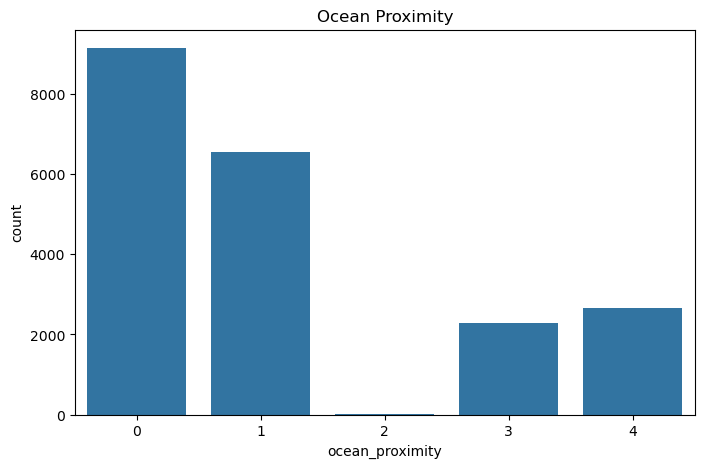

In [22]:

plt.figure(figsize=(8,5))
sns.countplot(x="ocean_proximity",data=df)
plt.title("Ocean Proximity")
plt.show()

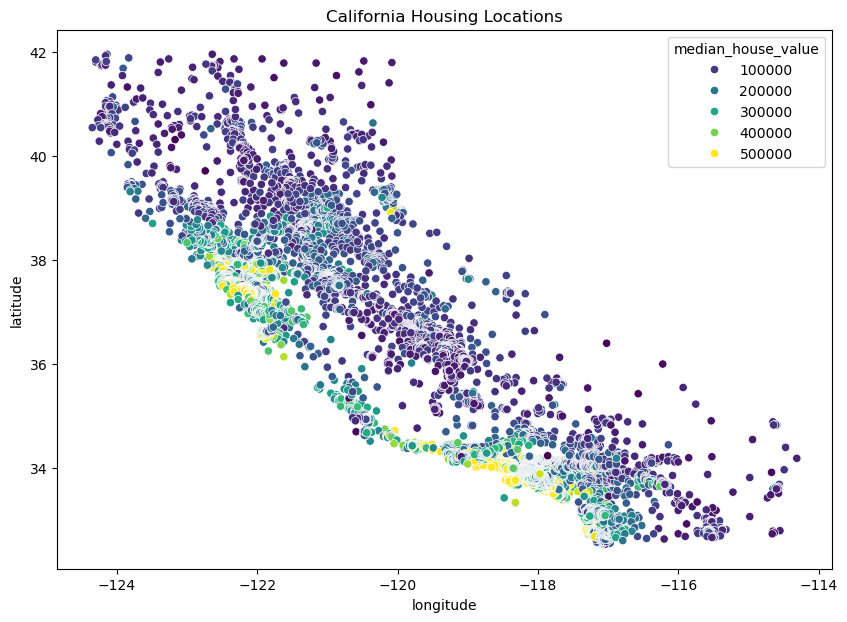

In [23]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="median_house_value",
    palette="viridis"
)
plt.title("California Housing Locations")
plt.show()

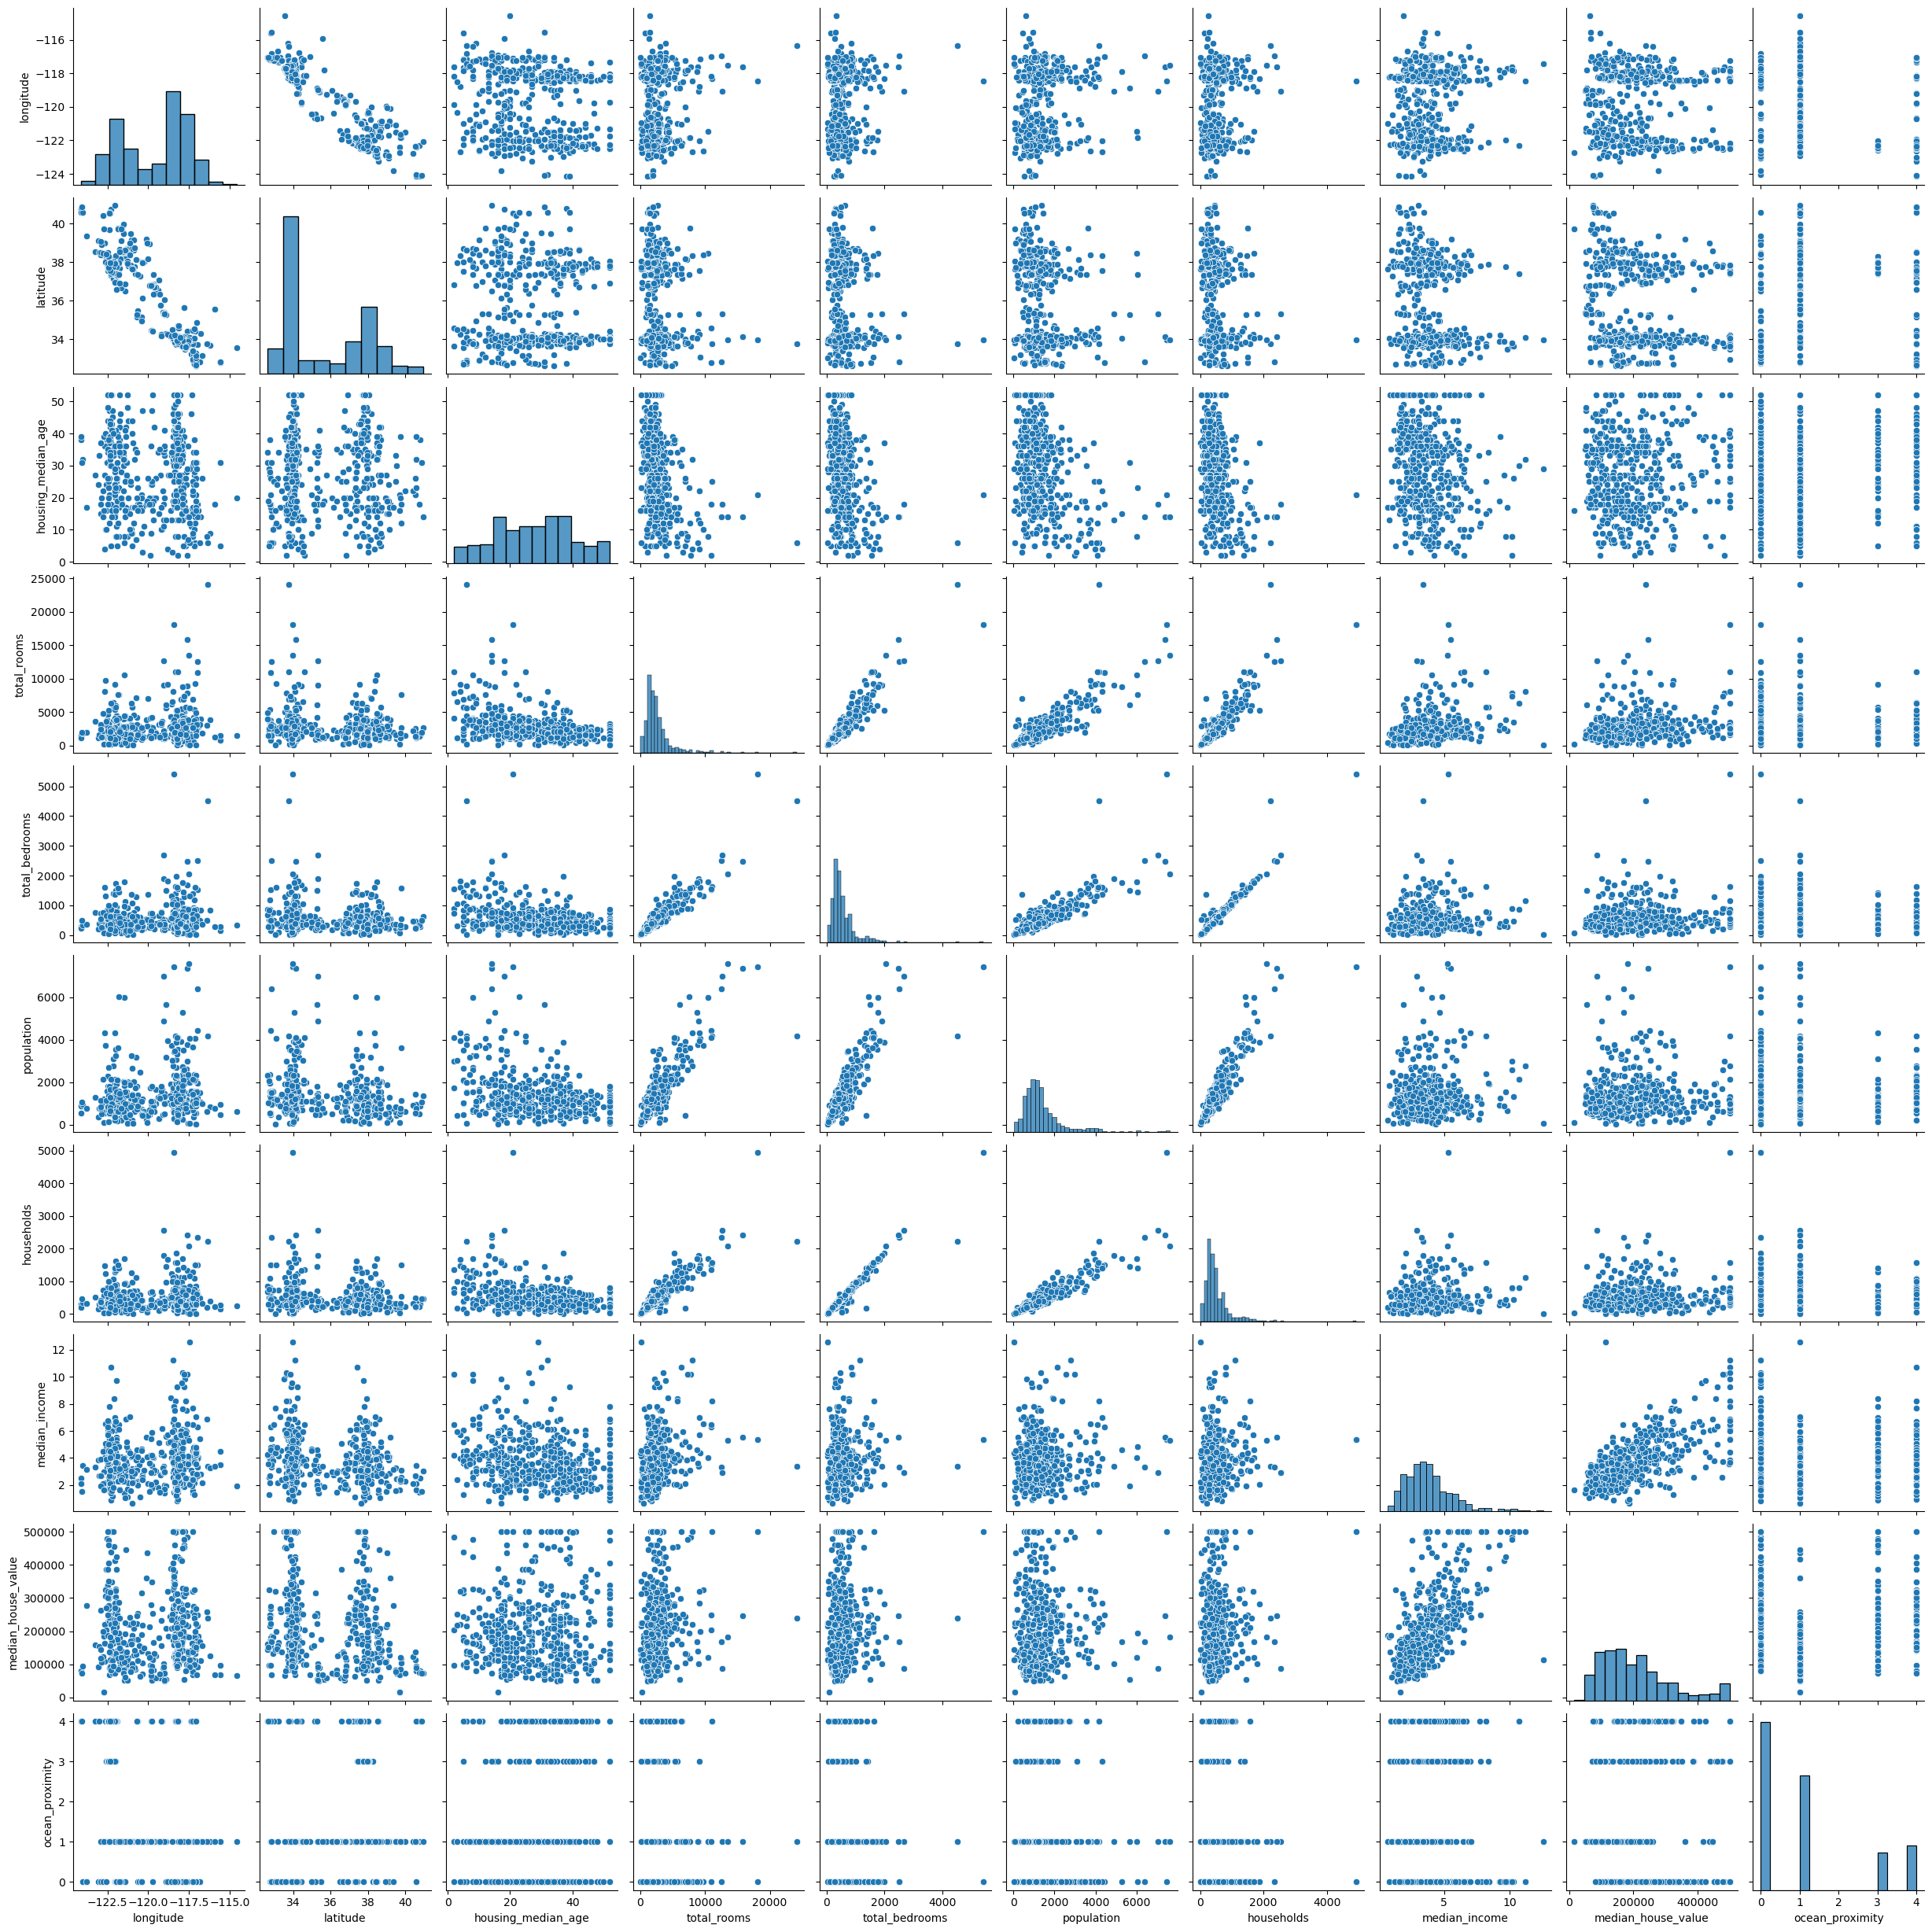


EDA Completed Successfully!


In [25]:
sns.pairplot(df.sample(500))
plt.show()

print("\nEDA Completed Successfully!")


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import numpy as np

In [29]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]
y

0        452600
1        358500
2        352100
3        341300
4        342200
          ...  
20635     78100
20636     77100
20637     92300
20638     84700
20639     89400
Name: median_house_value, Length: 20640, dtype: int64

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)


Training Data: (16512, 9)
Testing Data : (4128, 9)


In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n========== Linear Regression ==========")
print("R2 Score :", r2_score(y_test, lr_pred))
print("MAE      :", mean_absolute_error(y_test, lr_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, lr_pred)))



========== Linear Regression ==========
R2 Score : 0.6137068886499543
MAE      : 51820.74815026186
RMSE     : 71147.87146118368


In [32]:

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\n========== Decision Tree ==========")
print("R2 Score :", r2_score(y_test, dt_pred))
print("MAE      :", mean_absolute_error(y_test, dt_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, dt_pred)))


========== Decision Tree ==========
R2 Score : 0.641807096779449
MAE      : 43650.38468992248
RMSE     : 68511.25428149624


In [33]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n========== Random Forest ==========")
print("R2 Score :", r2_score(y_test, rf_pred))
print("MAE      :", mean_absolute_error(y_test, rf_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, rf_pred)))


========== Random Forest ==========
R2 Score : 0.8074523972118022
MAE      : 32156.728011143416
RMSE     : 50231.07677846623


In [34]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
print(results)


MODEL COMPARISON
               Model  R2 Score           MAE          RMSE
0  Linear Regression  0.613707  51820.748150  71147.871461
1      Decision Tree  0.641807  43650.384690  68511.254281
2      Random Forest  0.807452  32156.728011  50231.076778


In [35]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("\nBest Model")
print(best_model)


Best Model
Model       Random Forest
R2 Score         0.807452
MAE          32156.728011
RMSE         50231.076778
Name: 2, dtype: object



Feature Importance
              Feature  Importance
7       median_income    0.519625
8     ocean_proximity    0.109350
1            latitude    0.107798
0           longitude    0.105225
2  housing_median_age    0.055058
5          population    0.034408
4      total_bedrooms    0.024813
3         total_rooms    0.024733
6          households    0.018990


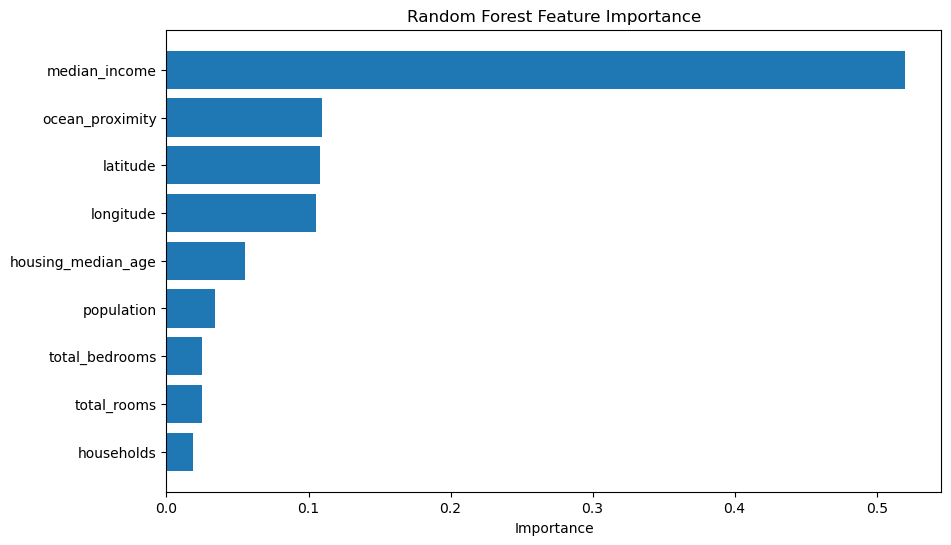

In [36]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

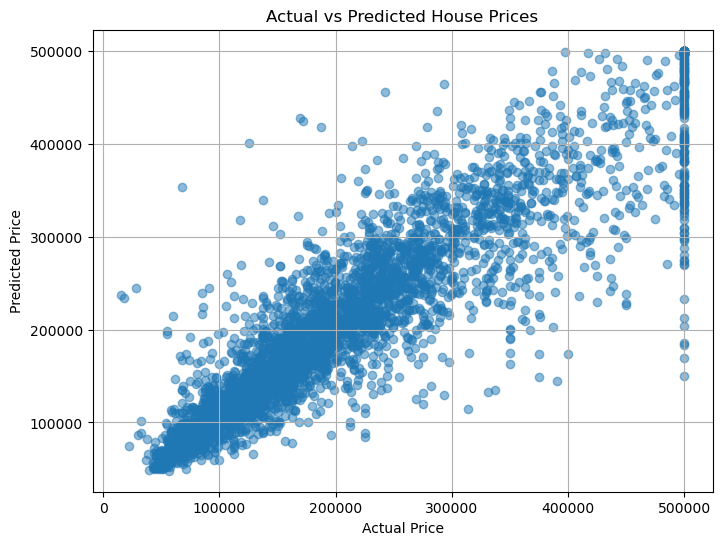

In [37]:

plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()


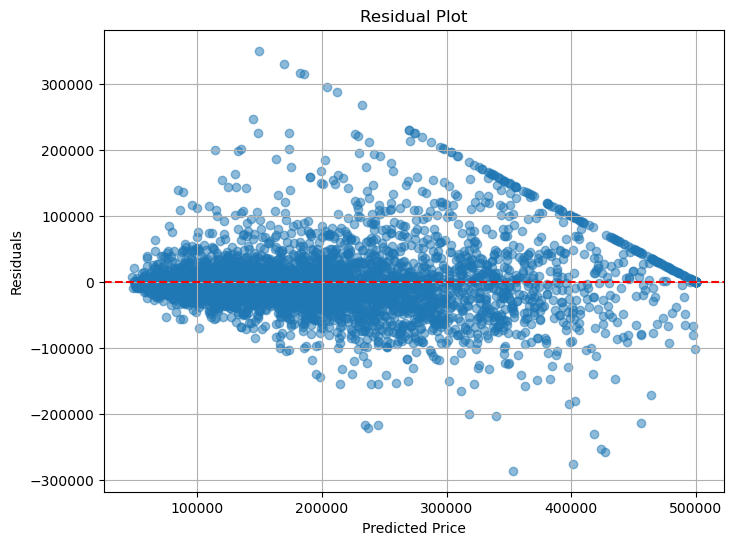

In [38]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))
plt.scatter(rf_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [39]:
joblib.dump(rf, "house_price_model.pkl")

print("\nModel Saved Successfully!")
print("File Name : house_price_model.pkl")


Model Saved Successfully!
File Name : house_price_model.pkl


In [40]:
import joblib
import pandas as pd

In [41]:
model = joblib.load("house_price_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [47]:
sample_house = pd.DataFrame({
    "longitude": [-122.23],
    "latitude": [37.88],
    "housing_median_age": [41],
    "total_rooms": [880],
    "total_bedrooms": [129],
    "population": [322],
    "households": [126],
    "median_income": [8.3252],
    "ocean_proximity": [3]   # Use the encoded value from Part 1
})

predicted_price = model.predict(sample_house)

print("\nPredicted House Price")
print(f"${predicted_price[0]:,.2f}")


Predicted House Price
$425,952.33


In [ ]:
print("\n========== Enter House Details ==========")

longitude = float(input("Longitude: "))
latitude = float(input("Latitude: "))
housing_age = int(input("Housing Median Age: "))
rooms = int(input("Total Rooms: "))
bedrooms = int(input("Total Bedrooms: "))
population = int(input("Population: "))
households = int(input("Households: "))
income = float(input("Median Income: "))
ocean = int(input("Ocean Proximity (Encoded): "))

new_house = pd.DataFrame({
    "longitude": [longitude],
    "latitude": [latitude],
    "housing_median_age": [housing_age],
    "total_rooms": [rooms],
    "total_bedrooms": [bedrooms],
    "population": [population],
    "households": [households],
    "median_income": [income],
    "ocean_proximity": [ocean]
})


========== Enter House Details ==========


In [ ]:
result = pd.DataFrame({
    "Predicted House Price": prediction
})

result.to_csv("prediction_result.csv", index=False)

print("\nPrediction saved as prediction_result.csv")

print("\nProject Completed Successfully!")